#



## 0. Cài đặt thư viện

In [1]:
# chỉ chạy một lần nếu chưa cài đặt các thư viện cần thiết
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm pandas Pillow


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


#



## 1. Import & Cấu hình

In [2]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

from src.dataset import build_dataloaders
from src.models import build_model
from src.train import train_model
from src.evaluate import evaluate_model, compare_models
from src.utils import plot_all, plot_model_comparison

CONFIG = {
    "data_dir"       : "./data",
    "output_dir"     : "./outputs",
    "img_size"       : 224,
    "epochs"         : 20,
    "lr"             : 1e-4,
    "weight_decay"   : 1e-4,
    "dropout"        : 0.3,
    "drop_path_rate" : 0.1,
    "patience"       : 7,
    "num_workers"    : 0,
    "batch_resnet"   : 16,
    "batch_convnext" : 16,
    "batch_vit"      : 16,
}

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Config : {CONFIG}")

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB
Config : {'data_dir': './data', 'output_dir': './outputs', 'img_size': 224, 'epochs': 20, 'lr': 0.0001, 'weight_decay': 0.0001, 'dropout': 0.3, 'drop_path_rate': 0.1, 'patience': 7, 'num_workers': 0, 'batch_resnet': 16, 'batch_convnext': 16, 'batch_vit': 16}


## 2. Load dữ liệu

In [3]:
# Dùng CHUNG 1 bộ DataLoader cho ResNet + ConvNeXt
train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders(
    data_dir         = CONFIG["data_dir"],
    img_size         = CONFIG["img_size"],
    batch_size_train = CONFIG["batch_resnet"],
    batch_size_eval  = 32,
    num_workers      = CONFIG["num_workers"],
)

# Train loader riêng cho ViT (batch_size nhỏ hơn)
train_loader_vit, _, _, _, _ = build_dataloaders(
    data_dir         = CONFIG["data_dir"],
    img_size         = CONFIG["img_size"],
    batch_size_train = CONFIG["batch_vit"],
    batch_size_eval  = 32,
    num_workers      = CONFIG["num_workers"],
)

print(f"\nClass names  : {class_names}")
print(f"Train batches: {len(train_loader)} | ViT train: {len(train_loader_vit)}")
print(f"Val batches  : {len(val_loader)} | Test: {len(test_loader)}")

[Data] Classes : ['normal', 'pneumonia', 'tuberculosis']
[Data] Train=20450 | Val=2534 | Test=2569
[Data] Class weights : [0.8805191516876221, 1.368252158164978, 0.7512287497520447]
[Data] Classes : ['normal', 'pneumonia', 'tuberculosis']
[Data] Train=20450 | Val=2534 | Test=2569
[Data] Class weights : [0.8805191516876221, 1.368252158164978, 0.7512287497520447]

Class names  : ['normal', 'pneumonia', 'tuberculosis']
Train batches: 1279 | ViT train: 1279
Val batches  : 80 | Test: 81


### Kiểm tra một batch mẫu

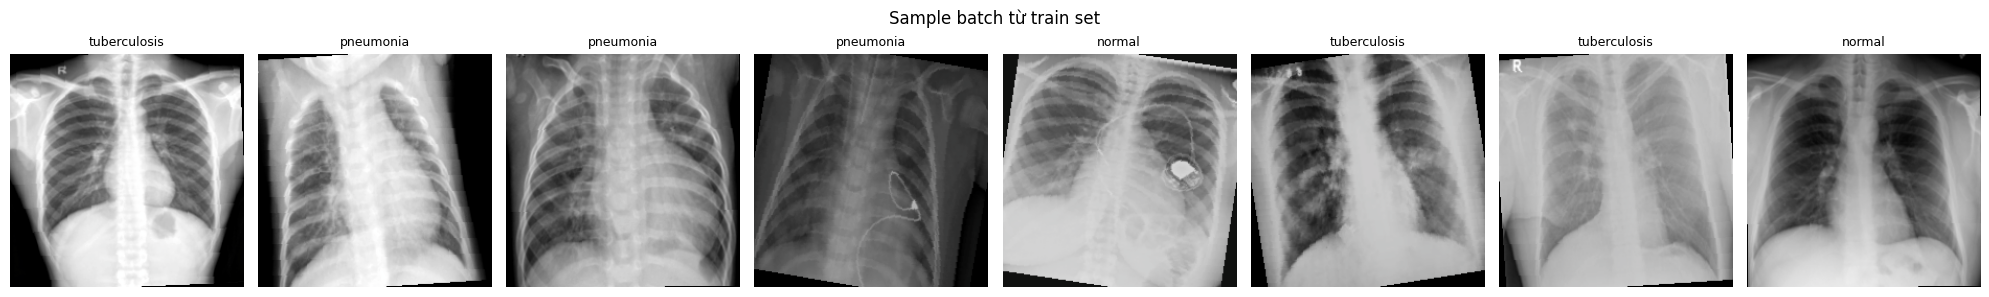

In [4]:
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * STD + MEAN, 0, 1)

images, labels = next(iter(train_loader))  # đổi train_loader_r → train_loader
n_show = min(8, len(images))

fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
for i, ax in enumerate(axes):
    ax.imshow(denormalize(images[i]))
    ax.set_title(class_names[labels[i].item()], fontsize=9)
    ax.axis("off")

plt.suptitle("Sample batch từ train set", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Huấn luyện ResNet-50

In [ ]:
model_resnet = build_model(
    model_name = "resnet50",
    n_classes  = len(class_names),
    img_size   = CONFIG["img_size"],
    dropout    = CONFIG["dropout"],
)

history_resnet = train_model(
    model         = model_resnet,
    train_loader  = train_loader,      # đổi từ train_loader_r
    val_loader    = val_loader,        # đổi từ val_loader_r
    class_weights = class_weights,
    device        = device,
    epochs        = CONFIG["epochs"],
    lr            = CONFIG["lr"],
    weight_decay  = CONFIG["weight_decay"],
    patience      = CONFIG["patience"],
    output_dir    = CONFIG["output_dir"],
    model_name    = "resnet50",
)

### Training curves – ResNet-50

In [16]:
from src.utils import plot_training_curves
plot_training_curves(history_resnet, model_name="resnet50", output_dir=CONFIG["output_dir"])
plt.show()

NameError: name 'history_resnet' is not defined

#



## 4. Huấn luyện ConvNeXt-Tiny

In [ ]:
model_convnext = build_model(
    model_name     = "convnext",
    n_classes      = len(class_names),
    img_size       = CONFIG["img_size"],
    dropout        = CONFIG["dropout"],
    drop_path_rate = CONFIG["drop_path_rate"],
)

history_convnext = train_model(
    model         = model_convnext,
    train_loader  = train_loader,
    val_loader    = val_loader,
    class_weights = class_weights,
    device        = device,
    epochs        = CONFIG["epochs"],
    lr            = CONFIG["lr"],
    weight_decay  = CONFIG["weight_decay"],
    patience      = CONFIG["patience"],
    output_dir    = CONFIG["output_dir"],
    model_name    = "convnext",
)

### Training curves – ConvNeXt-Tiny

In [ ]:
plot_training_curves(history_convnext, model_name="convnext", output_dir=CONFIG["output_dir"])
plt.show()

## 5. Huấn luyện ViT

In [5]:
model_vit = build_model(
    model_name = "vit",
    n_classes  = len(class_names),
    img_size   = CONFIG["img_size"],
    dropout    = CONFIG["dropout"],
)

history_vit = train_model(
    model         = model_vit,
    train_loader  = train_loader_vit,      
    val_loader    = val_loader,        # dùng chung val_loader
    class_weights = class_weights,
    device        = device,
    epochs        = CONFIG["epochs"],
    lr            = CONFIG["lr"],
    weight_decay  = CONFIG["weight_decay"],
    patience      = CONFIG["patience"],
    output_dir    = CONFIG["output_dir"],
    model_name    = "vit",
)

[Model] ViT-Tiny/16 | n_classes=3 | img_size=224
[Model] Total params: 5,524,995 | Trainable: 5,524,995


[vit] Epoch   1/20 | Loss 0.7739/0.7825 | F1 0.5867/0.6459 | Time 464.6s


  ✓ Best model saved (val F1=0.6459)


[vit] Epoch   2/20 | Loss 0.5823/0.8071 | F1 0.6984/0.6537 | Time 547.7s


  ✓ Best model saved (val F1=0.6537)


...

[vit] Epoch  17/20 | Loss 0.3858/0.5592 | F1 0.7797/0.7314 | Time 326.2s


[vit] Epoch  18/20 | Loss 0.3901/0.5321 | F1 0.7818/0.7356 | Time 325.6s


[vit] Epoch  19/20 | Loss 0.3922/0.5193 | F1 0.7788/0.7401 | Time 327.1s


  ✓ Best model saved (val F1=0.7401)


[vit] Epoch  20/20 | Loss 0.3869/0.5286 | F1 0.7812/0.7379 | Time 325.8s
[vit] Training done. Best val F1 = 0.7401


### Training curves – ViT

[Plot] Saved ./outputs\vit_training_curves.png


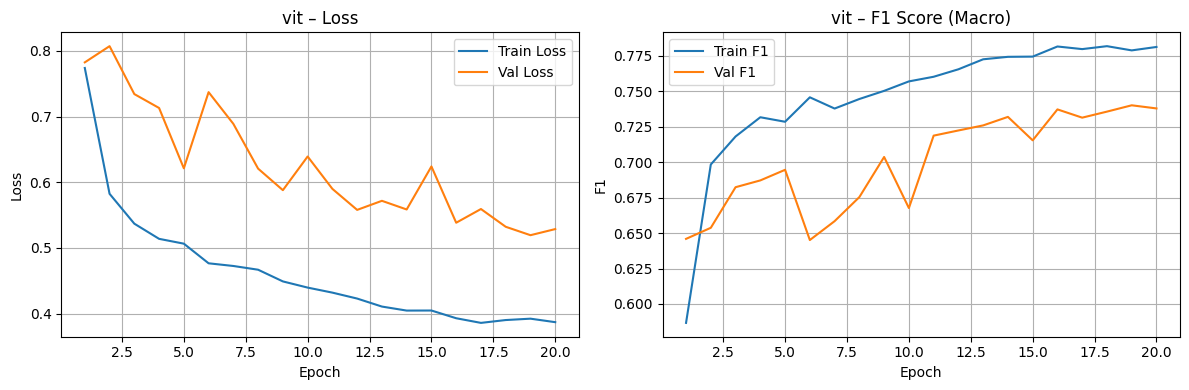

In [9]:
from src.utils import plot_training_curves
plot_training_curves(history_vit, model_name="vit", output_dir=CONFIG["output_dir"])
plt.show()

#



## 6. Đánh giá trên tập Test

In [11]:
metrics_resnet = evaluate_model(
    #model       = model_resnet,
    #test_loader = test_loader,
    #class_names = class_names,
    device      = device,
    output_dir  = CONFIG["output_dir"],
    model_name  = "resnet50",
)

TypeError: evaluate_model() missing 3 required positional arguments: 'model', 'test_loader', and 'class_names'

In [ ]:
metrics_convnext = evaluate_model(
    model       = model_convnext,
    test_loader = test_loader,
    class_names = class_names,
    device      = device,
    output_dir  = CONFIG["output_dir"],
    model_name  = "convnext",
)

In [12]:
metrics_vit = evaluate_model(
    model       = model_vit,
    test_loader = test_loader,
    class_names = class_names,
    device      = device,
    output_dir  = CONFIG["output_dir"],
    model_name  = "vit",
)


  VIT — Test Results
  Accuracy  : 0.7404
  F1 (macro): 0.7511
  Precision : 0.7786
  Recall    : 0.7813
  ROC-AUC   : 0.8973

  Per-class Sensitivity & Specificity:
    normal                Sens=0.8011  Spec=0.7251
    pneumonia             Sens=0.9931  Spec=0.9015
    tuberculosis          Sens=0.5498  Spec=0.9874

  Model params  : 5,524,995
  VRAM peak     : 143.6 MB
  Inference     : 15.37 ms/image

              precision    recall  f1-score   support

      normal       0.62      0.80      0.70       925
   pneumonia       0.75      0.99      0.85       580
tuberculosis       0.97      0.55      0.70      1064

    accuracy                           0.74      2569
   macro avg       0.78      0.78      0.75      2569
weighted avg       0.79      0.74      0.73      2569



#



## 7. Biểu đồ & So sánh

FileNotFoundError: [Errno 2] No such file or directory: './outputs\\ViT-Tiny/16_confusion_matrix.png'

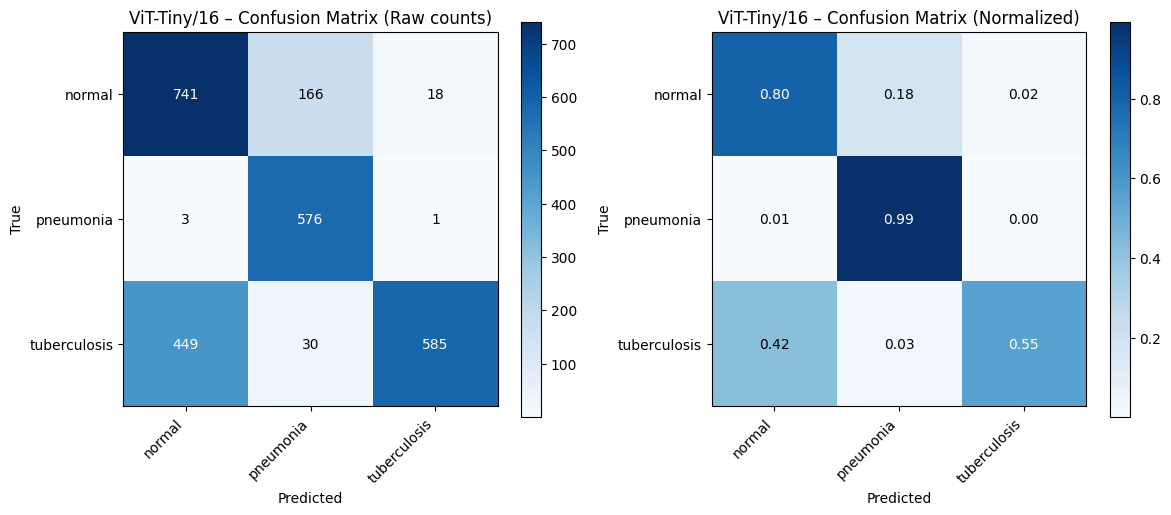

In [15]:
from src.utils import plot_confusion_matrix, plot_roc_curve

metrics_by_model = {
    #"ResNet-50": metrics_resnet,
    #"ConvNeXt-Tiny": metrics_convnext,
    "ViT-Tiny/16": metrics_vit,
}

for model_name, metrics in metrics_by_model.items():
    plot_confusion_matrix(
        metrics["y_true"], metrics["y_pred"],
        class_names, model_name, CONFIG["output_dir"],
    )
    plt.show()

In [13]:
for model_name, metrics in metrics_by_model.items():
    plot_roc_curve(
        metrics["y_true"], metrics["y_proba"],
        class_names, model_name, CONFIG["output_dir"],
    )
    plt.show()

NameError: name 'metrics_by_model' is not defined

In [ ]:
compare_models(metrics_by_model)
plot_model_comparison(metrics_by_model, output_dir=CONFIG["output_dir"])
plt.show()

## 8. Tổng kết

Tất cả checkpoint (`.pth`) và biểu đồ (`.png`) đã được lưu vào thư mục `outputs/`.

| File | Nội dung |
|---|---|
| `resnet50_best.pth` | Best checkpoint ResNet-50 |
| `convnext_best.pth` | Best checkpoint ConvNeXt-Tiny |
| `vit_best.pth`| Best checkpoint ViT|
| `*_training_curves.png` | Loss & F1 theo epoch |
| `*_confusion_matrix.png` | Confusion Matrix (raw + normalized) |
| `*_roc_curve.png` | ROC Curve per-class + macro |
| `model_comparison.png` | Bar chart so sánh 3 model |